<a href="https://colab.research.google.com/github/Paddy-0708/Projects/blob/main/stock_market_perdiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance pandas numpy matplotlib statsmodels tensorflow scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

data = data.reset_index()

print(data.head())

/tmp/ipykernel_2586/1266066239.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price        Date      Close       High        Low       Open     Volume
Ticker                  AAPL       AAPL       AAPL       AAPL       AAPL
0      2015-01-02  24.214891  24.682224  23.776352  24.671149  212818400
1      2015-01-05  23.532719  24.064282  23.346673  23.984547  257142000
2      2015-01-06  23.534933  23.794069  23.173912  23.596948  263188400
3      2015-01-07  23.864950  23.964618  23.632391  23.743133  160423600
4      2015-01-08  24.781897  24.839483  24.075361  24.192749  237458000


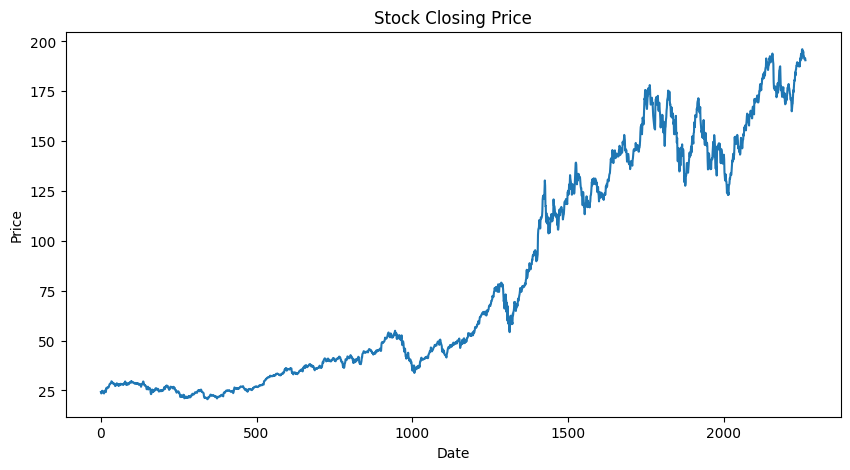

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(data["Close"])

plt.title("Stock Closing Price")

plt.xlabel("Date")
plt.ylabel("Price")

plt.show()


In [ ]:
delta = data["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

data["RSI"] = 100 - (100/(1+rs))

print(data.tail())

Price        Date       Close        High  ...        Open    Volume        RSI
Ticker                   AAPL        AAPL  ...        AAPL      AAPL           
2259   2023-12-22  191.609451  193.400839  ...  193.173193  37149600  59.246023
2260   2023-12-26  191.065140  191.896500  ...  191.619380  28919300  49.031962
2261   2023-12-27  191.164108  191.510516  ...  190.510906  48087700  52.291609
2262   2023-12-28  191.589691  192.658589  ...  192.143931  34049900  47.920477
2263   2023-12-29  190.550446  192.401214  ...  191.906355  42672100  40.185159

[5 rows x 7 columns]


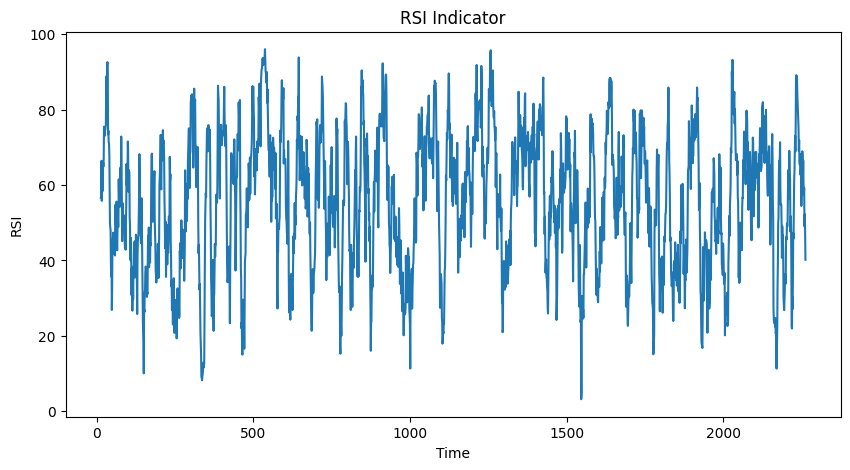

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(data["RSI"].dropna())

plt.title("RSI Indicator")

plt.xlabel("Time")
plt.ylabel("RSI")

plt.show()

In [ ]:
exp1 = data["Close"].ewm(span=12, adjust=False).mean()
exp2 = data["Close"].ewm(span=26, adjust=False).mean()

data["MACD"] = exp1-exp2

data["Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()

print(data.tail())

Price        Date       Close        High  ...        RSI      MACD    Signal
Ticker                   AAPL        AAPL  ...                               
2259   2023-12-22  191.609451  193.400839  ...  59.246023  2.630678  3.232230
2260   2023-12-26  191.065140  191.896500  ...  49.031962  2.302597  3.046303
2261   2023-12-27  191.164108  191.510516  ...  52.291609  2.027208  2.842484
2262   2023-12-28  191.589691  192.658589  ...  47.920477  1.822294  2.638446
2263   2023-12-29  190.550446  192.401214  ...  40.185159  1.558080  2.422373

[5 rows x 9 columns]


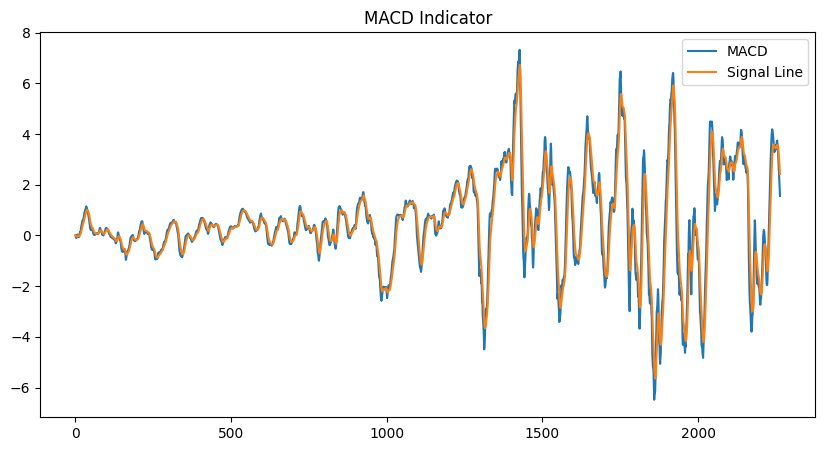

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(data["MACD"],label="MACD")

plt.plot(data["Signal"],label="Signal Line")

plt.legend()

plt.title("MACD Indicator")

plt.show()

In [ ]:
model = ARIMA(data["Close"], order=(5,1,0))

model_fit = model.fit()

forecast = model_fit.forecast(steps=10)

print("Next 10 predicted prices:")
print(forecast)

Next 10 predicted prices:
2264    190.536958
2265    190.535182
2266    190.551152
2267    190.570877
2268    190.528636
2269    190.529004
2270    190.529637
2271    190.530704
2272    190.531558
2273    190.529817
Name: predicted_mean, dtype: float64


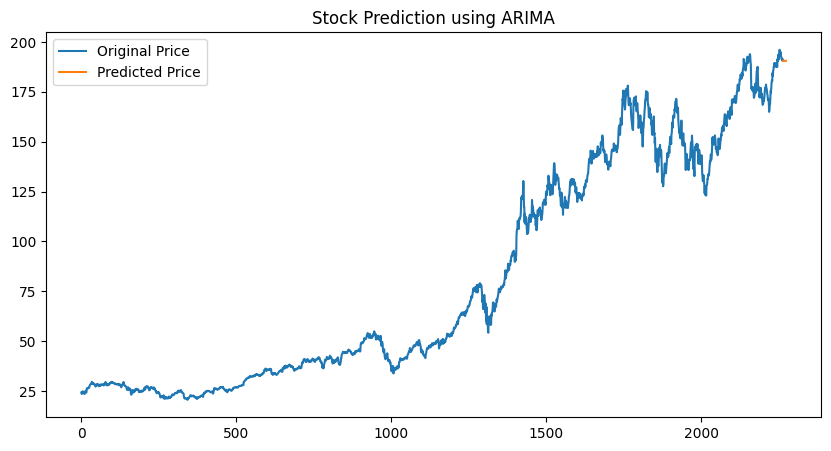

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(data["Close"],label="Original Price")

plt.plot(range(len(data),len(data)+10),forecast,label="Predicted Price")

plt.legend()

plt.title("Stock Prediction using ARIMA")

plt.show()

In [ ]:
close_data = data["Close"].values
close_data = close_data.reshape(-1,1)

X=[]
y=[]

for i in range(1,len(close_data)):
    X.append(close_data[i-1])
    y.append(close_data[i])

X=np.array(X)
y=np.array(y)

X=X.reshape((X.shape[0],1,X.shape[1]))

In [ ]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(1,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.fit(X,y,epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9458.3301
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8288.3730
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7634.7749
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7210.2798
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6842.0879


In [ ]:
predicted = model.predict(X)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


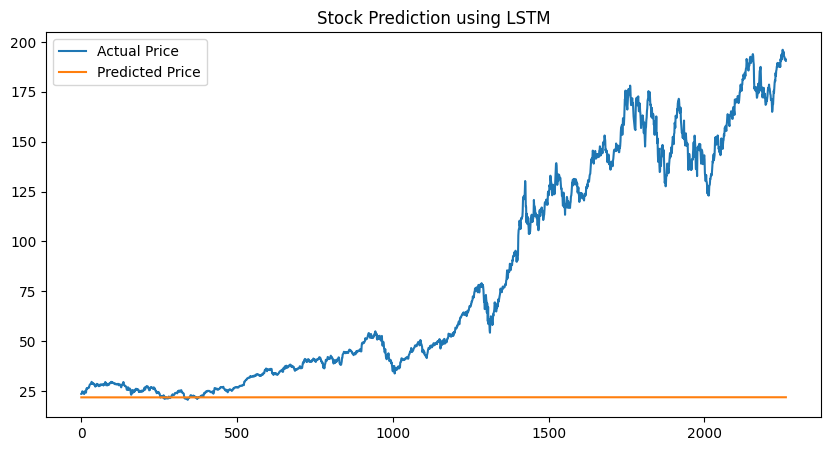

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y,label="Actual Price")

plt.plot(predicted,label="Predicted Price")

plt.legend()

plt.title("Stock Prediction using LSTM")

plt.show()